# Customer Retention & Churn Analysis

This notebook explores customer churn patterns and identifies the factors that influence customer retention. The goal is to provide actionable business recommendations for reducing churn and improving customer satisfaction.

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly
import kaleido

pd.set_option("display.max_columns", None)

In [39]:
df = pd.read_csv("../processed_data/Telco_Customer_Churn_Cleaned.csv")

In [40]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Flag,Customer_Type,Monthly_Spending
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,New Customer,Low
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0,Existing Customer,Medium
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,New Customer,Medium
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,Existing Customer,Medium
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,New Customer,High


## 1. Overall Customer Churn Rate

Understanding the overall churn rate provides a high-level view of customer retention. It helps measure the percentage of customers who have discontinued the service.

In [41]:
churn_rate = (
    df["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(churn_rate)

Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64


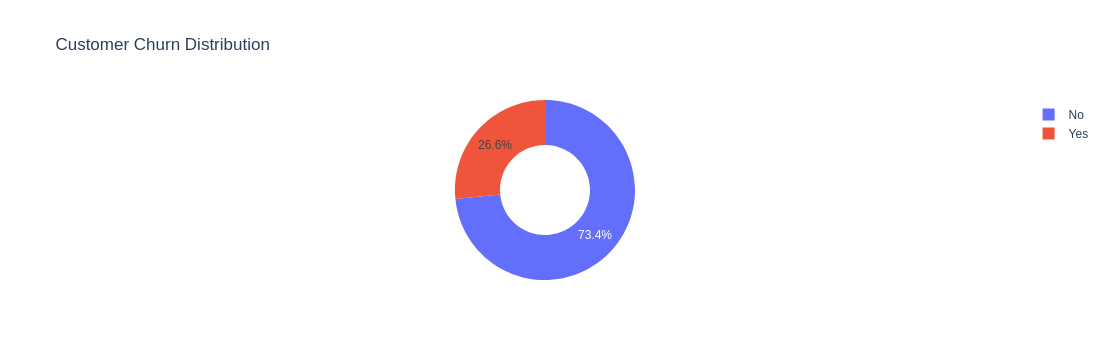

In [42]:
fig = px.pie(
    df,
    names="Churn",
    title="Customer Churn Distribution",
    hole=0.5
)

fig.show()

In [43]:
fig.write_image("../images/churn_distribution.png")

### Business Interpretation

Approximately **26.58%** of customers have churned, while **73.42%** remain with the company.

A churn rate of over one-quarter of the customer base is significant and indicates that customer retention should be a strategic priority. Further analysis will identify which customer segments contribute most to this churn and help recommend targeted retention strategies.

### Recommendation

With a customer churn rate of **26.58%**, improving customer retention should be a strategic priority for the company. The business should identify high-risk customer segments and implement targeted retention initiatives such as personalized offers, proactive customer support, loyalty programs, and incentives for long-term subscriptions. Reducing churn can significantly improve customer lifetime value and overall business profitability.

## 2. Churn by Contract Type

Contract duration often influences customer loyalty. This analysis examines whether customers on different contract plans exhibit different churn behaviors.

In [44]:
contract_churn = (
    df.groupby("Contract")["Churn_Flag"]
    .mean()
    .mul(100)
    .round(2)
    .reset_index()
)

contract_churn

,Contract,Churn_Flag
0,Month-to-month,42.71
1,One year,11.28
2,Two year,2.85


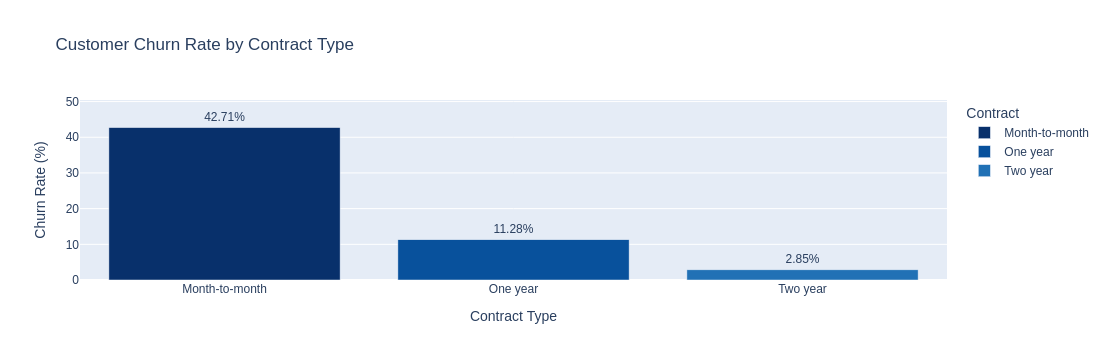

In [45]:
fig = px.bar(
    contract_churn,
    x="Contract",
    y="Churn_Flag",
    color="Contract",
    title="Customer Churn Rate by Contract Type",
    text="Churn_Flag",
    color_discrete_sequence=px.colors.sequential.Blues_r
)

fig.update_traces(texttemplate="%{text:.2f}%", textposition="outside")

fig.update_layout(
    xaxis_title="Contract Type",
    yaxis_title="Churn Rate (%)"
)

fig.show()

In [46]:
fig.write_image("../images/churn_by_contract.png")

### Business Interpretation

Customers on **month-to-month contracts** have the highest churn rate (**42.71%**), significantly exceeding customers on **one-year (11.28%)** and **two-year (2.85%)** contracts.

This indicates that long-term contracts are strongly associated with improved customer retention. Customers who commit to longer subscription periods are far less likely to discontinue the service.

### Recommendation

The company should encourage month-to-month customers to upgrade to annual or two-year plans by offering discounts, loyalty rewards, or exclusive benefits. Increasing long-term contract adoption could substantially reduce customer churn.

## 3. Churn by Gender

This analysis explores whether customer churn differs significantly between male and female customers.

In [47]:
gender_churn = (
    df.groupby("gender")["Churn_Flag"]
    .mean()
    .mul(100)
    .round(2)
    .reset_index()
)

gender_churn

,gender,Churn_Flag
0,Female,26.96
1,Male,26.20


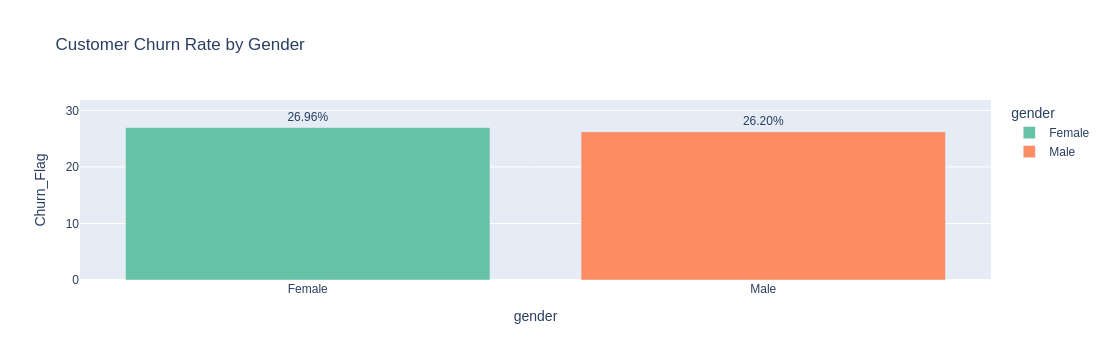

In [48]:
fig = px.bar(
    gender_churn,
    x="gender",
    y="Churn_Flag",
    color="gender",
    title="Customer Churn Rate by Gender",
    text="Churn_Flag",
    color_discrete_sequence=px.colors.qualitative.Set2
)

fig.update_traces(texttemplate="%{text:.2f}%", textposition="outside")

fig.show()

### Business Interpretation

Customer churn rates are nearly identical for female (**26.96%**) and male (**26.20%**) customers.

This suggests that gender is not a significant factor influencing customer churn. Instead, the company should focus on service quality, contract type, pricing, and customer experience when designing retention strategies.

### Recommendation

Retention initiatives should target customer behavior and subscription characteristics rather than demographic factors such as gender.

## 4. Churn by Internet Service

Internet service quality can significantly influence customer satisfaction and retention. This analysis compares churn rates across different internet service types.

In [49]:
internet_churn = (
    df.groupby("InternetService")["Churn_Flag"]
    .mean()
    .mul(100)
    .round(2)
    .reset_index()
)

internet_churn

,InternetService,Churn_Flag
0,DSL,19.00
1,Fiber optic,41.89
2,No,7.43


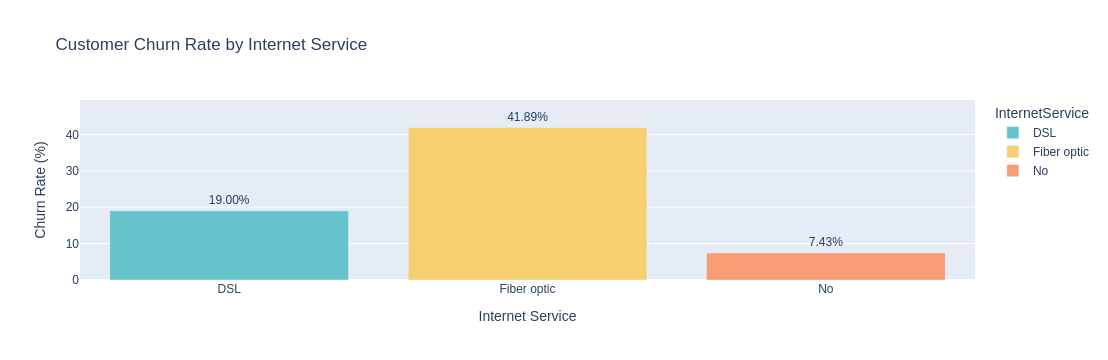

In [50]:
fig = px.bar(
    internet_churn,
    x="InternetService",
    y="Churn_Flag",
    color="InternetService",
    title="Customer Churn Rate by Internet Service",
    text="Churn_Flag",
    color_discrete_sequence=px.colors.qualitative.Pastel
)

fig.update_traces(texttemplate="%{text:.2f}%", textposition="outside")

fig.update_layout(
    xaxis_title="Internet Service",
    yaxis_title="Churn Rate (%)"
)

fig.show()

In [51]:
fig.write_image("../images/churn_by_internet_service.png")

### Business Interpretation

Customers using **Fiber optic internet** experience the highest churn rate (**41.89%**), compared with **DSL (19.00%)** and customers without internet service (**7.43%**).

This suggests that Fiber optic customers are considerably more likely to leave the company. Possible reasons may include higher pricing, unmet service expectations, or increased competition in high-speed internet offerings.

### Recommendation

The company should prioritize retaining Fiber optic customers by investigating service quality, pricing, customer support, and competitive offerings. Targeted promotions and proactive customer engagement could significantly reduce churn within this high-risk segment.

## 5. Churn by Payment Method

Payment methods may influence customer retention by affecting convenience, billing reliability, and customer satisfaction. This analysis compares churn rates across different payment methods.

In [52]:
payment_churn = (
    df.groupby("PaymentMethod")["Churn_Flag"]
    .mean()
    .mul(100)
    .round(2)
    .reset_index()
)

payment_churn

,PaymentMethod,Churn_Flag
0,Bank transfer (automatic),16.73
1,Credit card (automatic),15.25
2,Electronic check,45.29
3,Mailed check,19.20


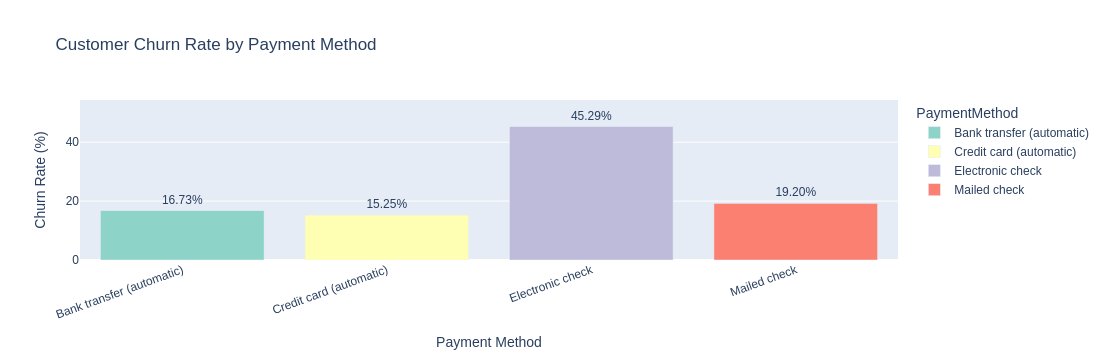

In [53]:
fig = px.bar(
    payment_churn,
    x="PaymentMethod",
    y="Churn_Flag",
    color="PaymentMethod",
    title="Customer Churn Rate by Payment Method",
    text="Churn_Flag",
    color_discrete_sequence=px.colors.qualitative.Set3
)

fig.update_traces(
    texttemplate="%{text:.2f}%",
    textposition="outside"
)

fig.update_layout(
    xaxis_title="Payment Method",
    yaxis_title="Churn Rate (%)",
    xaxis_tickangle=-20
)

fig.show()

In [54]:
fig.write_image("../images/churn_by_payment_method.png")

### Business Interpretation

Customers using **Electronic Check** have the highest churn rate at **45.29%**, making them the most at-risk payment segment.

Customers paying via **Bank Transfer (16.73%)**, **Credit Card (15.25%)**, and **Mailed Check (19.20%)** show substantially lower churn rates.

This suggests that customers using automatic or more convenient payment methods are more likely to stay with the company, while electronic check users may experience lower engagement, payment friction, or belong to higher-risk customer groups.

### Recommendation
Encourage customers to switch from electronic checks to automatic payment methods such as bank transfers or credit cards through discounts, incentives, or simplified payment setup to improve retention.

## 6. Churn by Customer Tenure

Customer tenure represents the length of time a customer has remained with the company. Analyzing tenure helps identify whether customers are more likely to churn during the early stages of their relationship or after becoming long-term subscribers.

Understanding this pattern enables the business to design targeted retention strategies at the most critical points in the customer lifecycle.

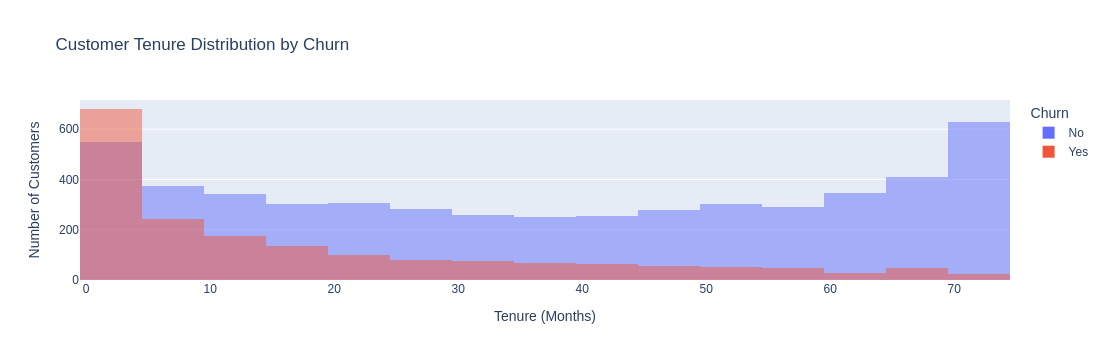

In [55]:
fig = px.histogram(
    df,
    x="tenure",
    color="Churn",
    nbins=30,
    barmode="overlay",
    title="Customer Tenure Distribution by Churn",
    labels={"tenure": "Customer Tenure (Months)"}
)

fig.update_layout(
    xaxis_title="Tenure (Months)",
    yaxis_title="Number of Customers"
)

fig.show()

In [56]:
fig.write_image("../images/churn_by_tenure.png")

### Business Interpretation

The tenure distribution shows that customers are much more likely to churn during the early months of their subscription. As customer tenure increases, the likelihood of churn decreases significantly, indicating stronger loyalty among long-term customers.

This suggests that the first year of the customer lifecycle is the most vulnerable period for customer attrition.

### Recommendation

The company should strengthen its onboarding process and customer engagement during the first year. Providing proactive support, personalized communication, and loyalty incentives to new customers can improve customer satisfaction and significantly reduce early churn.

## 7. Monthly Charges vs Customer Churn

Pricing is an important factor that can influence customer retention. This analysis examines whether customers with higher monthly charges are more likely to discontinue the service.

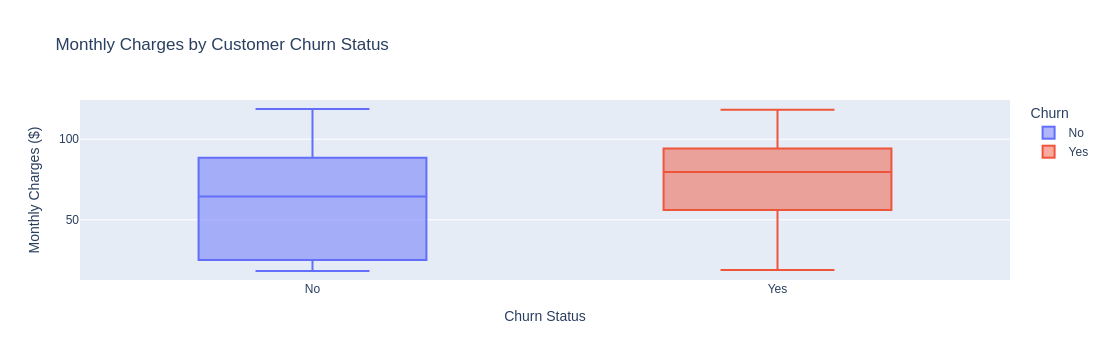

In [57]:
fig = px.box(
    df,
    x="Churn",
    y="MonthlyCharges",
    color="Churn",
    title="Monthly Charges by Customer Churn Status"
)

fig.update_layout(
    xaxis_title="Churn Status",
    yaxis_title="Monthly Charges ($)"
)

fig.show()

In [58]:
fig.write_image("../images/monthly_charges_vs_churn.png")

### Business Interpretation

Customers who churn have noticeably higher monthly charges than those who remain with the company. The average monthly charge for churned customers is **\$74.44**, compared to **\$61.31** for retained customers. Similarly, the median monthly charge is higher for churned customers (**\$79.65**) than for retained customers (**\$64.45**).

This suggests that higher recurring costs may contribute to customer dissatisfaction or encourage customers to switch to competitors offering better value.

### Recommendation

The company should review its pricing strategy for customers with higher monthly charges. Offering personalized discounts, bundled service packages, loyalty rewards, or premium customer support to high-value customers could improve perceived value and reduce churn among this segment.

## 8. Total Charges vs Customer Churn

Total charges represent the cumulative amount spent by a customer throughout their relationship with the company. This analysis helps determine whether long-term, high-value customers are more or less likely to churn.

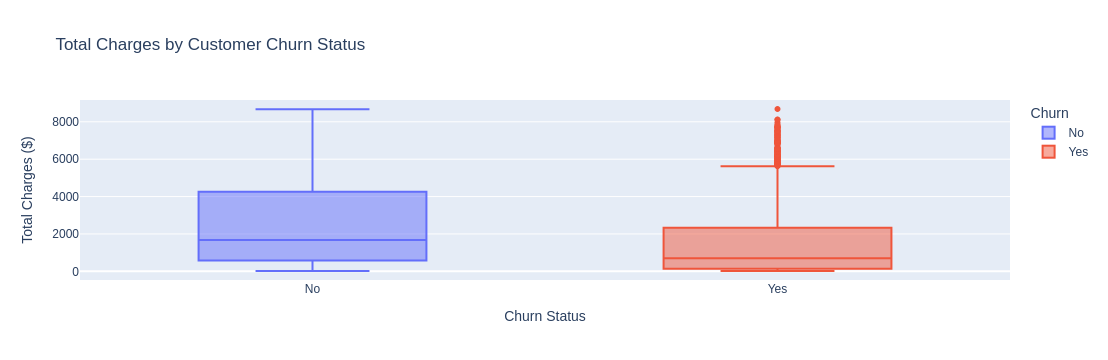

In [59]:
fig = px.box(
    df,
    x="Churn",
    y="TotalCharges",
    color="Churn",
    title="Total Charges by Customer Churn Status"
)

fig.update_layout(
    xaxis_title="Churn Status",
    yaxis_title="Total Charges ($)"
)

fig.show()

In [60]:
df.groupby("Churn")["TotalCharges"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,2555.34,2329.46,18.80,577.83,1683.60,4264.12,8672.45
Yes,1869.0,1531.80,1890.82,18.85,134.50,703.55,2331.30,8684.80


### Business Interpretation

Customers who remained with the company have significantly higher total charges than customers who churned. The average total charges for retained customers are **\$2555.34**, compared to **\$1531.80** for churned customers. Similarly, the median total charges are much higher for retained customers (**\$1683.60**) than for churned customers (**\$703.55**).

This indicates that customers who stay longer naturally contribute more revenue over their lifetime, while customers who churn tend to leave before generating substantial long-term value.

### Business Recommendation

The company should focus on retaining customers during their early months of service. Improving early customer satisfaction, onboarding, and engagement can increase customer lifetime value by encouraging customers to remain subscribed for longer periods.

# 9. Key Business Findings

Based on the customer retention analysis, the following insights were identified:

1. The overall customer churn rate is **26.58%**, indicating that more than one in four customers discontinue the service.

2. Customers on **month-to-month contracts** have the highest churn rate (42.71%), while two-year contracts exhibit the strongest customer retention.

3. **Fiber optic customers** experience the highest churn among internet service types, suggesting potential concerns regarding pricing, service quality, or customer expectations.

4. Customers using **Electronic Check** as their payment method have the highest churn rate (45.29%), whereas automatic payment methods show considerably lower churn.

5. Customer churn is concentrated during the **early months** of the customer lifecycle, highlighting the importance of effective onboarding and early engagement.

6. Customers who churn generally pay **higher monthly charges** but accumulate **lower total charges**, indicating that many leave before becoming long-term, high-value customers.

# 10. Strategic Business Recommendations

Based on the findings, the following actions are recommended to improve customer retention:

- Encourage customers to switch from month-to-month subscriptions to long-term contracts through discounts and loyalty incentives.

- Investigate the reasons behind the high churn among Fiber optic customers by evaluating pricing, service quality, and customer support.

- Promote automatic payment methods such as bank transfers and credit cards to reduce churn associated with Electronic Check payments.

- Improve customer onboarding by providing proactive support and personalized engagement during the first year of service.

- Offer targeted discounts or bundled plans to customers with high monthly charges to improve perceived value.

- Continuously monitor customer behavior using retention dashboards and predictive analytics to identify high-risk customers before they churn.

# 11. Conclusion

This analysis identified several key factors associated with customer churn, including contract type, internet service, payment method, tenure, and monthly charges.

The findings indicate that customer retention can be significantly improved by focusing on long-term customer engagement, optimizing pricing strategies, enhancing service quality, and encouraging long-term subscriptions.

Implementing these recommendations can help increase customer lifetime value, reduce churn, and support sustainable business growth.